In [2]:
# carga de libreria

import yfinance as yf #yahoofinance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, t

In [3]:
# descarga y carga de la información

stock = "LMT"
df = yf.download(stock, start="2010-05-01", auto_adjust=False)


[*********************100%***********************]  1 of 1 completed


In [4]:
# obtenemos los rendimientos diarios y eliminamos los na

prices = df["Adj Close"]
returns = np.log(prices/prices.shift(1)).dropna()

if isinstance(returns, pd.DataFrame):
    returns = returns.squeeze()

In [5]:
# Obtenemos la esperanza, sesgo y nivel de curtosis

mean = returns.mean()
bias = returns.skew()
kurtosis = returns.kurtosis()

print("Media: {} \n" 
      "Sesgo: {} \n"
      "Curtosis: {}".format(mean,bias,kurtosis))

Media: 0.0005643676839565774 
Sesgo: -0.7637741375057836 
Curtosis: 13.261170179102484


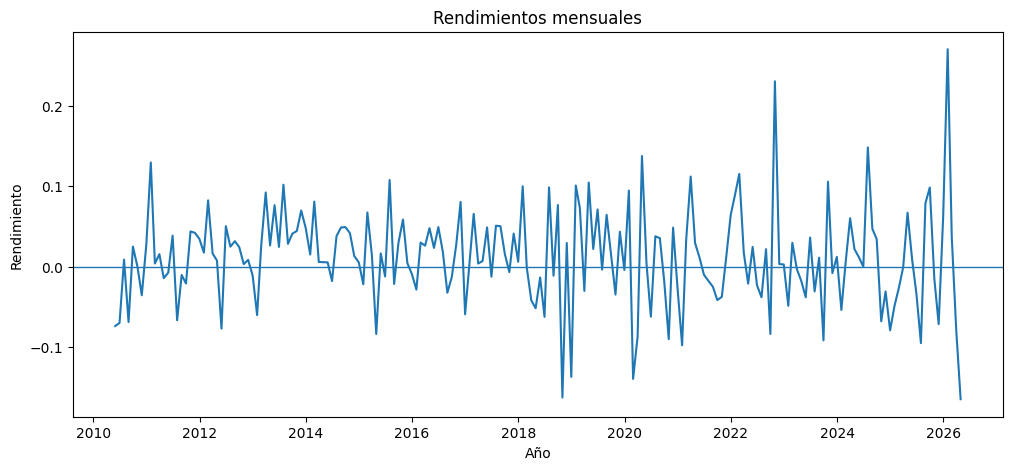

In [6]:
# graficamos los rendimientos   

monthly_returns = returns.resample("ME").sum()

plt.figure(figsize=(12,5))
plt.plot(monthly_returns.index, monthly_returns.values)
plt.title("Rendimientos mensuales")
plt.xlabel("Año")
plt.ylabel("Rendimiento")
plt.axhline(0, linewidth=1)
plt.show()



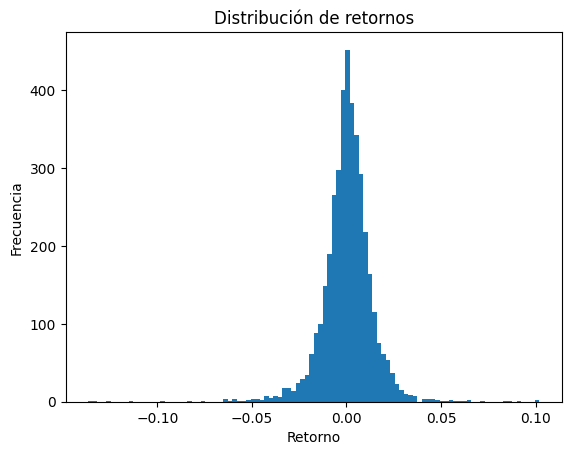

In [7]:
plt.figure()
plt.hist(returns, bins=100)
plt.title("Distribución de retornos")
plt.xlabel("Retorno")
plt.ylabel("Frecuencia")
plt.show()

In [8]:
# calculo del Value at Risk y Expected Shortfall


confidence_leveles = [0.95, 0.975, 0.99]
mu = returns.mean()
sigma = returns.std(ddof=1)
n = 10000 
nu,loc, scale = t.fit(returns)
simulated_returns = np.random.normal(mu, sigma, n)


#funciones 

#Var historico

def var_es_historico(x, alpha):
    p = 1 - alpha
    var = np.quantile(x,p)
    es  = x[x<=var].mean()
    return var, es 

def var_es_normal(mu, sigma, alpha):
    p = 1 - alpha
    z = norm.ppf(p)
    var = mu + (sigma * z)
    es = mu - (sigma * norm.pdf(z)/p)
    return var, es

def var_es_t_student(alpha):
    p = 1 - alpha
    q = t.ppf(p,df=nu)
    var = mu + (sigma * np.sqrt((nu-2)/nu)) * q
    es = mu - (sigma * np.sqrt((nu-2)/nu)) * ((nu + q**2) / (nu - 1)) * (t.pdf(q, df=nu)/ p)
    return var, es

def var_es_montecarlo(simulated_returns, alpha):
    p = 1 - alpha
    var = np.quantile(simulated_returns,p)
    es = simulated_returns[simulated_returns <= var].mean()
    return var, es

results = []

for alpha in confidence_leveles:
    var_n, es_n = var_es_normal(mu, sigma, alpha)
    var_t, es_t = var_es_t_student(alpha)
    var_h, es_h = var_es_historico(returns, alpha)
    var_mc, es_mc = var_es_montecarlo(simulated_returns, alpha)
    
    results.append({
        "Nivel de confianza": alpha,
        "VaR Normal": var_n,
        "ES Normal": es_n,
        "VaR t-Student": var_t,
        "ES t-Student": es_t,
        "VaR Histórico": var_h,
        "ES Histórico": es_h,
        "VaR Monte Carlo": var_mc,
        "ES Monte Carlo": es_mc
    })

tabla_resultados = pd.DataFrame(results)


In [9]:
# format0 resultados

tabla_pct = tabla_resultados.copy()

for col in tabla_pct.columns[1:]:
    tabla_pct[col] = tabla_pct[col] * 100

print(tabla_pct.round(4))


tabla_pct_redondeada = tabla_pct.copy()
tabla_pct_redondeada.iloc[:, 1:] = tabla_pct_redondeada.iloc[:, 1:].round(4)
tabla_pct_redondeada

   Nivel de confianza  VaR Normal  ES Normal  VaR t-Student  ES t-Student  \
0               0.950     -2.1876    -2.7577        -1.8622       -3.0232   
1               0.975     -2.6175    -3.1330        -2.5122       -3.9045   
2               0.990     -3.1174    -3.5797        -3.5546       -5.3588   

   VaR Histórico  ES Histórico  VaR Monte Carlo  ES Monte Carlo  
0        -1.9028       -3.2396          -2.1416         -2.7320  
1        -2.6533       -4.2456          -2.5762         -3.1290  
2        -3.7965       -5.8642          -3.0929         -3.6221  


,Nivel de confianza,VaR Normal,ES Normal,VaR t-Student,ES t-Student,VaR Histórico,ES Histórico,VaR Monte Carlo,ES Monte Carlo
0,0.950,-2.1876,-2.7577,-1.8622,-3.0232,-1.9028,-3.2396,-2.1416,-2.7320
1,0.975,-2.6175,-3.1330,-2.5122,-3.9045,-2.6533,-4.2456,-2.5762,-3.1290
2,0.990,-3.1174,-3.5797,-3.5546,-5.3588,-3.7965,-5.8642,-3.0929,-3.6221


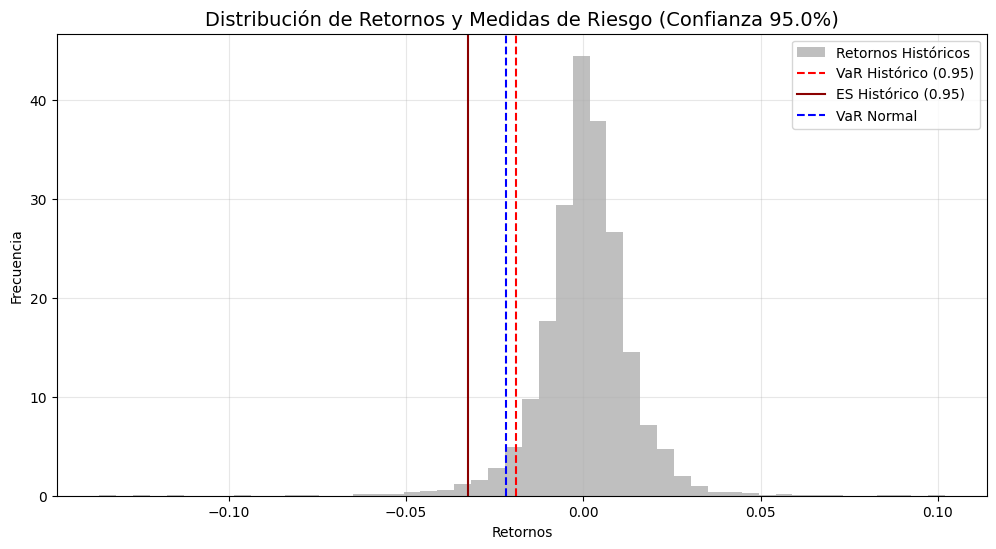

In [10]:
# Elegimos un nivel de confianza para visualizar (ej. 95%)
alpha_plot = 0.95
# Extraemos los valores calculados para ese alpha de tu tabla
row = tabla_resultados[tabla_resultados["Nivel de confianza"] == alpha_plot].iloc[0]

plt.figure(figsize=(12, 6))

# 1. Histograma de los retornos reales
plt.hist(returns, bins=50, alpha=0.5, color='gray', label='Retornos Históricos', density=True)

# 2. Líneas para VaR y ES Histórico
plt.axvline(row['VaR Histórico'], color='red', linestyle='--', label=f'VaR Histórico ({alpha_plot})')
plt.axvline(row['ES Histórico'], color='darkred', linestyle='-', label=f'ES Histórico ({alpha_plot})')

# 3. Línea para VaR Normal (para comparar)
plt.axvline(row['VaR Normal'], color='blue', linestyle='--', label=f'VaR Normal')

# Personalización
plt.title(f'Distribución de Retornos y Medidas de Riesgo (Confianza {alpha_plot*100}%)', fontsize=14)
plt.xlabel('Retornos')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

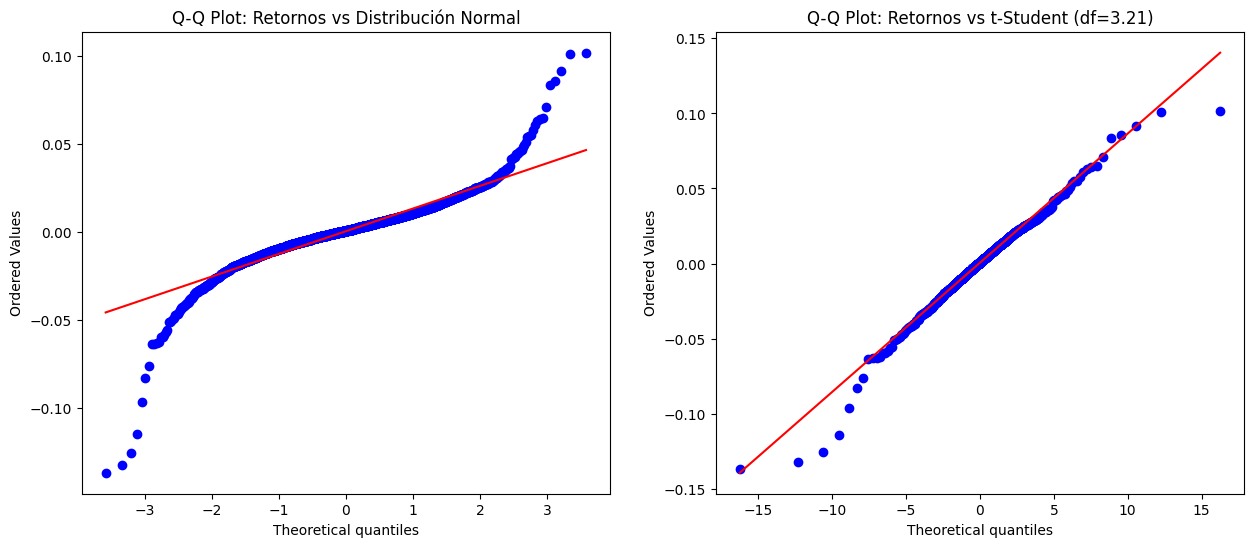

In [12]:
import matplotlib.pyplot as plt
from scipy import stats  # <-- ¡Esta es la línea clave!

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Q-Q Plot contra la Normal
stats.probplot(returns, dist="norm", plot=ax1)
ax1.set_title("Q-Q Plot: Retornos vs Distribución Normal")

# Q-Q Plot contra la t-Student
# Asegúrate de que la variable 'nu' ya esté calculada en tu entorno
stats.probplot(returns, dist="t", sparams=(nu,), plot=ax2)
ax2.set_title(f"Q-Q Plot: Retornos vs t-Student (df={nu:.2f})")

plt.show()

In [13]:
from scipy import stats

# Usamos la prueba de Kolmogorov-Smirnov (kstest)
# Le pasamos los retornos, el nombre de la distribución ('t') 
# y los parámetros que calculaste antes con t.fit()
ks_stat, p_value = stats.kstest(returns, 't', args=(nu, loc, scale))

print(f"Estadístico K-S: {ks_stat:.4f}")
print(f"P-valor: {p_value:.4f}")
print("-" * 40)

# Interpretación estándar al 95% de confianza (alpha = 0.05)
if p_value < 0.05:
    print("Resultado: Rechazamos la hipótesis nula (H0).")
    print("Conclusión: Los datos NO siguen la distribución t-Student propuesta.")
else:
    print("Resultado: No podemos rechazar la hipótesis nula (H0).")
    print("Conclusión: Es estadísticamente plausible que los datos sigan una t-Student.")

Estadístico K-S: 0.0084
P-valor: 0.9394
----------------------------------------
Resultado: No podemos rechazar la hipótesis nula (H0).
Conclusión: Es estadísticamente plausible que los datos sigan una t-Student.


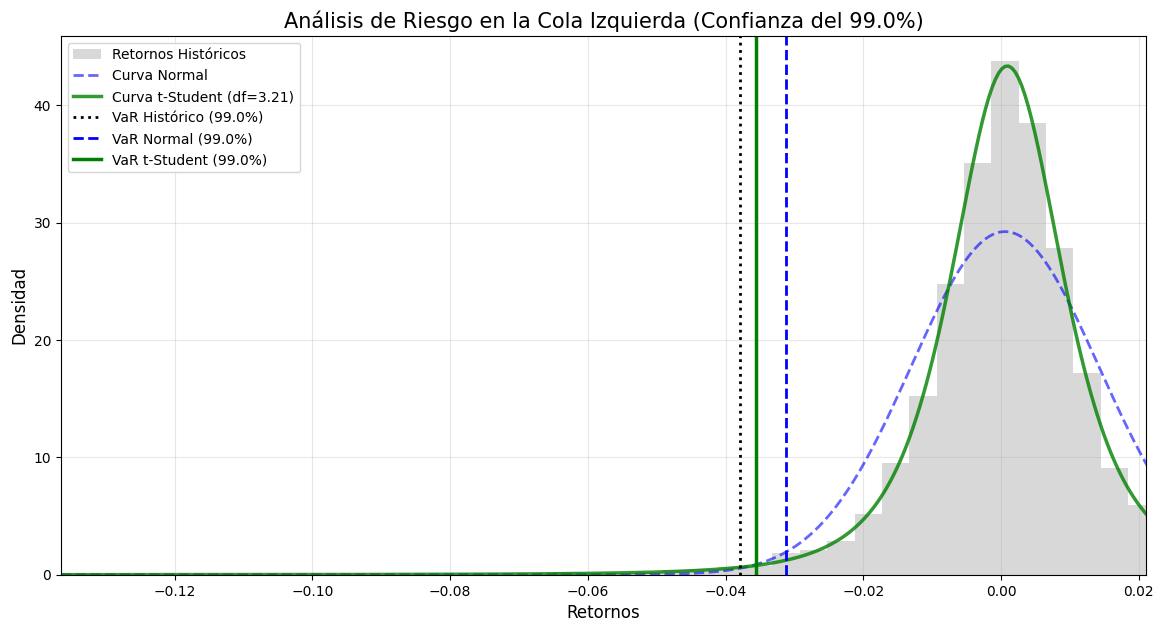

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# 1. Elegimos un nivel de confianza exigente para ver bien la cola (ej. 99%)
alpha_plot = 0.99
row = tabla_resultados[tabla_resultados["Nivel de confianza"] == alpha_plot].iloc[0]

plt.figure(figsize=(14, 7))

# 2. Histograma empírico (fondo)
plt.hist(returns, bins=60, density=True, alpha=0.3, color='gray', label='Retornos Históricos')

# 3. Curvas teóricas superpuestas
x_rango = np.linspace(returns.min(), returns.max(), 500)

# Densidad Normal
plt.plot(x_rango, stats.norm.pdf(x_rango, mu, sigma), 'b--', alpha=0.6, lw=2, label='Curva Normal')

# Densidad t-Student (usando tus parámetros)
plt.plot(x_rango, stats.t.pdf(x_rango, nu, loc, scale), 'g-', alpha=0.8, lw=2.5, label=f'Curva t-Student (df={nu:.2f})')

# 4. Líneas de VaR en la cola izquierda
plt.axvline(row['VaR Histórico'], color='black', linestyle=':', lw=2, label=f'VaR Histórico ({alpha_plot*100}%)')
plt.axvline(row['VaR Normal'], color='blue', linestyle='--', lw=2, label=f'VaR Normal ({alpha_plot*100}%)')
plt.axvline(row['VaR t-Student'], color='green', linestyle='-', lw=2.5, label=f'VaR t-Student ({alpha_plot*100}%)')

# 5. Truco Pro: Hacer zoom en la cola izquierda (pérdidas)
# Recortamos el gráfico para que no muestre las ganancias altas y nos deje ver bien el riesgo
plt.xlim(returns.min(), returns.mean() + (1.5 * sigma)) 

# Detalles estéticos
plt.title(f'Análisis de Riesgo en la Cola Izquierda (Confianza del {alpha_plot*100}%)', fontsize=15)
plt.xlabel('Retornos', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(alpha=0.3)

plt.show()

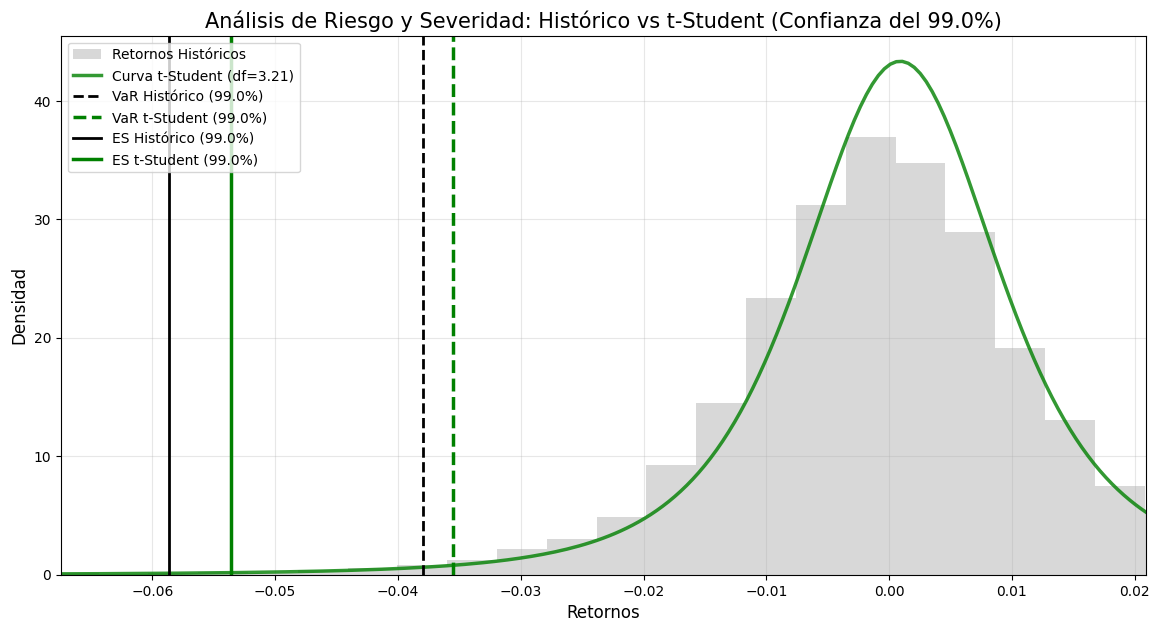

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

# 1. Elegimos un nivel de confianza exigente para ver bien la cola (ej. 99%)
alpha_plot = 0.99
row = tabla_resultados[tabla_resultados["Nivel de confianza"] == alpha_plot].iloc[0]

plt.figure(figsize=(14, 7))

# 2. Histograma empírico (fondo)
plt.hist(returns, bins=60, density=True, alpha=0.3, color='gray', label='Retornos Históricos')

# 3. Curva teórica superpuesta (Solo t-Student)
x_rango = np.linspace(returns.min(), returns.max(), 500)
plt.plot(x_rango, stats.t.pdf(x_rango, nu, loc, scale), 'g-', alpha=0.8, lw=2.5, label=f'Curva t-Student (df={nu:.2f})')

# 4. Líneas de VaR (Límites) en la cola izquierda
plt.axvline(row['VaR Histórico'], color='black', linestyle='--', lw=2, label=f'VaR Histórico ({alpha_plot*100}%)')
plt.axvline(row['VaR t-Student'], color='green', linestyle='--', lw=2.5, label=f'VaR t-Student ({alpha_plot*100}%)')

# 5. Líneas de ES (Severidad de la pérdida) aún más a la izquierda
plt.axvline(row['ES Histórico'], color='black', linestyle='-', lw=2, label=f'ES Histórico ({alpha_plot*100}%)')
plt.axvline(row['ES t-Student'], color='green', linestyle='-', lw=2.5, label=f'ES t-Student ({alpha_plot*100}%)')

# 6. Truco Pro: Hacer zoom en la cola izquierda (pérdidas)
# Ajustamos el límite izquierdo (xlim) basándonos en el peor ES para asegurarnos de que todo quepa en la gráfica
limite_izquierdo = min(row['ES Histórico'], row['ES t-Student']) * 1.15
plt.xlim(limite_izquierdo, returns.mean() + (1.5 * sigma)) 

# Detalles estéticos
plt.title(f'Análisis de Riesgo y Severidad: Histórico vs t-Student (Confianza del {alpha_plot*100}%)', fontsize=15)
plt.xlabel('Retornos', fontsize=12)
plt.ylabel('Densidad', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(alpha=0.3)

plt.show()

In [17]:
# implementacion del rolling window

window = 252
alphas = [0.95, 0.99]

# dataframe de los retornos
df_risk = pd.DataFrame({'Return':returns})

# calculo de rolling con desfase de un dia

# variable auxiliar

roll_mean = df_risk['Return'].rolling(window=window).mean().shift(1)
roll_std = df_risk['Return'].rolling(window=window).std(ddof=1).shift(1)


# funcion auxiliar del ES

def calc_es_hist_rolling(x,alpha):
    p = 1 - alpha
    var = np.quantile(x,p)
    return x[x <= var ].mean()


# calculo del var y del ES

for alpha in alphas:

    p = 1 - alpha

    z = norm.ppf(p)
    q_t = t.ppf(p, df=nu)
    adj_scale  = np.sqrt((nu-2)/nu)


    #normal 
df_risk[f'VaR_{int(alpha*100)}_Norm'] = roll_mean + (roll_std * z)
df_risk[f'ES_{int(alpha*100)}_Norm'] = roll_mean - (roll_std * norm.pdf(z) / p)

    #t-student

df_risk[f'VaR_{int(alpha*100)}_t'] = roll_mean + (roll_std * adj_scale) * q_t
df_risk[f'ES_{int(alpha*100)}_t'] = roll_mean - (roll_std * adj_scale) * ((nu + q_t**2) / (nu - 1)) * (t.pdf(q_t, df=nu) / p)

    #historico

df_risk[f'VaR_{int(alpha*100)}_Hist'] = df_risk['Return'].rolling(window=window).quantile(p).shift(1)
df_risk[f'ES_{int(alpha*100)}_Hist'] = df_risk['Return'].rolling(window=window).apply(
        calc_es_hist_rolling, args=(alpha,), raw=False
    ).shift(1)


df_risk = df_risk.dropna()

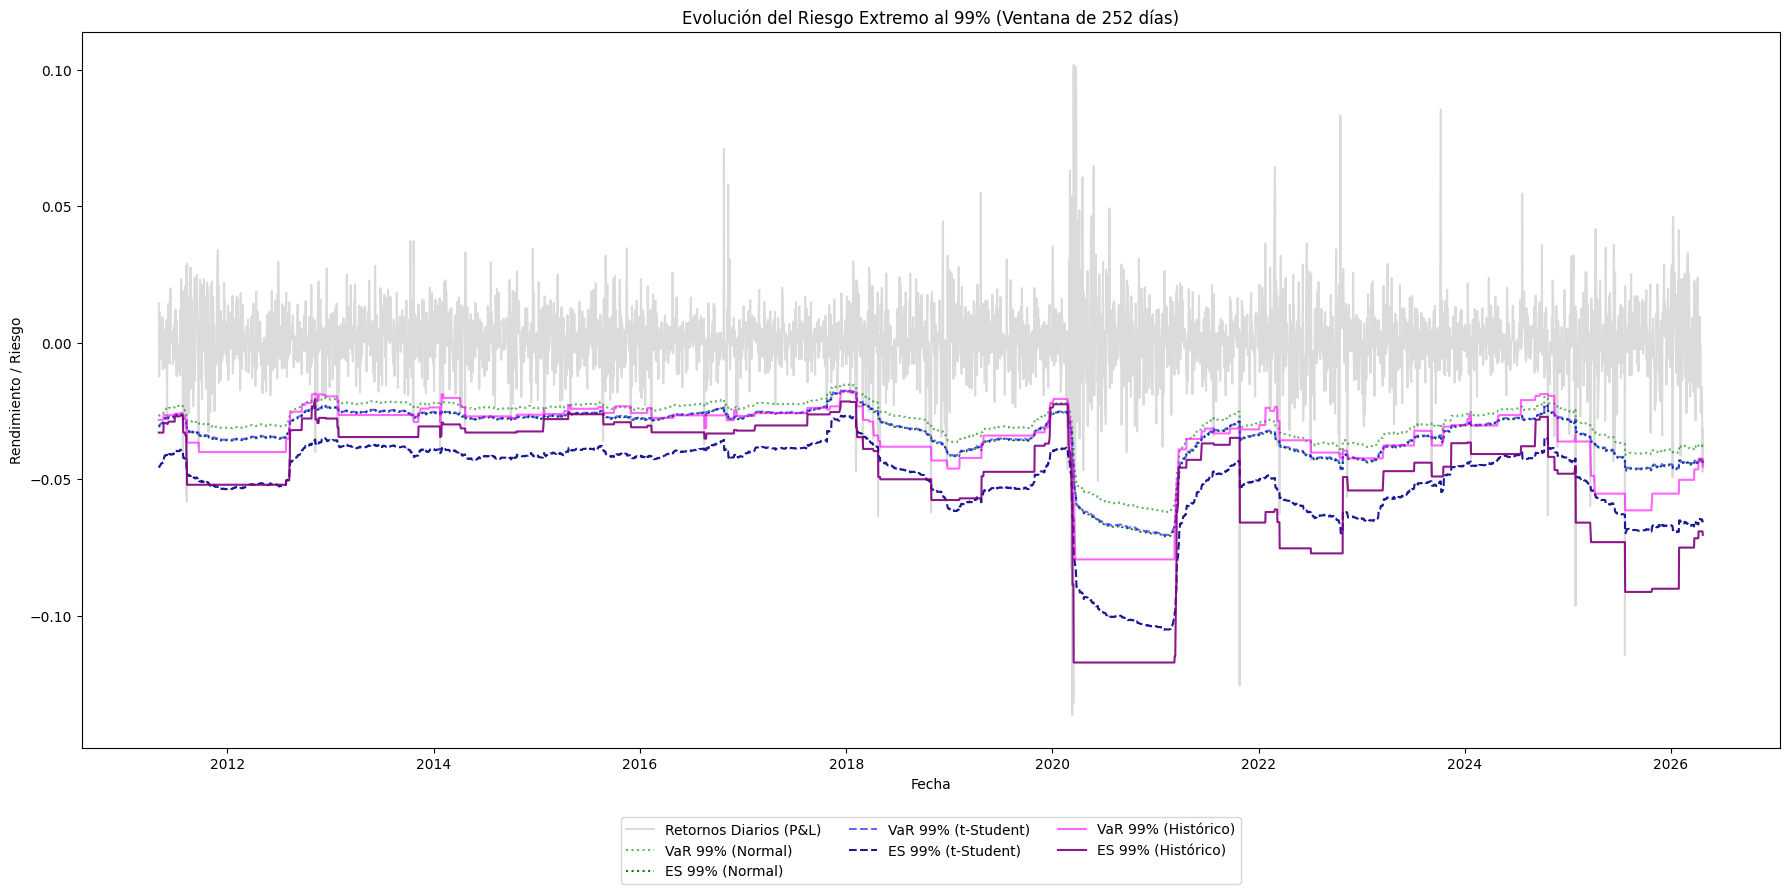

In [18]:
plt.figure(figsize=(18, 9))

# Graficamos P&L en el fondo
plt.plot(df_risk.index, df_risk['Return'], color='lightgrey', alpha=0.8, label='Retornos Diarios (P&L)')

# ----------------- GRAFICAMOS SOLO EL 99% PARA NO SATURAR LA GRÁFICA -----------------
# Si graficamos todos los niveles, serán 12 líneas y no se entenderá nada.
# Te muestro el riesgo más extremo (99%) como ejemplo.

# Normal
plt.plot(df_risk.index, df_risk['VaR_99_Norm'], linestyle=':', color='green', alpha=0.6, label='VaR 99% (Normal)')
plt.plot(df_risk.index, df_risk['ES_99_Norm'], linestyle=':', color='darkgreen', alpha=0.9, linewidth=1.5, label='ES 99% (Normal)')

# t-Student
plt.plot(df_risk.index, df_risk['VaR_99_t'], linestyle='--', color='blue', alpha=0.6, label='VaR 99% (t-Student)')
plt.plot(df_risk.index, df_risk['ES_99_t'], linestyle='--', color='darkblue', alpha=0.9, linewidth=1.5, label='ES 99% (t-Student)')

# Histórico
plt.plot(df_risk.index, df_risk['VaR_99_Hist'], linestyle='-', color='magenta', alpha=0.6, label='VaR 99% (Histórico)')
plt.plot(df_risk.index, df_risk['ES_99_Hist'], linestyle='-', color='purple', alpha=0.9, linewidth=1.5, label='ES 99% (Histórico)')

plt.title(f"Evolución del Riesgo Extremo al 99% (Ventana de {window} días)")
plt.xlabel("Fecha")
plt.ylabel("Rendimiento / Riesgo")

# Leyenda y formato
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3)
plt.tight_layout()
plt.show()

In [20]:
#=====================================================================
# BACKTESTING: CÁLCULO DE VIOLACIONES
# =====================================================================

# Total de días (observaciones) en nuestra muestra de prueba
n_obs = len(df_risk)
violaciones_results = []

# Obtenemos solo las columnas de riesgo que calculamos (excluyendo 'Return')
risk_columns = [col for col in df_risk.columns if col != 'Return']

for col in risk_columns:
    # Una violación ocurre si el retorno real es menor (más negativo) que la estimación
    num_violaciones = (df_risk['Return'] < df_risk[col]).sum()
    pct_violaciones = (num_violaciones / n_obs) * 100
    
    # Extraemos información del nombre de la columna (ej. VaR_95_Norm)
    partes = col.split('_')
    if len(partes) == 3:
        medida = partes[0]      # VaR o ES
        alpha = partes[1] + '%' # 95 o 99
        modelo = partes[2]      # Norm, t, Hist
        
        violaciones_results.append({
            'Medida': medida,
            'Nivel de Confianza': alpha,
            'Modelo': modelo,
            '# Violaciones': num_violaciones,
            '% de Violaciones': pct_violaciones
        })

# Convertimos a DataFrame para visualizarlo como tabla
df_violaciones = pd.DataFrame(violaciones_results)

# Ordenamos para que sea más fácil comparar
df_violaciones = df_violaciones.sort_values(by=['Nivel de Confianza', 'Medida', 'Modelo'])

# Imprimimos la tabla con un formato limpio
print("\n" + "="*50)
print("   RESUMEN DE VIOLACIONES (BACKTESTING)   ")
print("="*50)
print(f"Total de días evaluados (n): {n_obs}")
print("-" * 50)
# Mostramos el porcentaje redondeado a 2 decimales
print(df_violaciones.to_string(index=False, float_format="%.2f%%"))
print("="*50)


   RESUMEN DE VIOLACIONES (BACKTESTING)   
Total de días evaluados (n): 3767
--------------------------------------------------
Medida Nivel de Confianza Modelo  # Violaciones  % de Violaciones
    ES                99%   Hist             29             0.77%
    ES                99%   Norm             57             1.51%
    ES                99%      t             21             0.56%
   VaR                99%   Hist             61             1.62%
   VaR                99%   Norm             78             2.07%
   VaR                99%      t             60             1.59%


In [21]:
# =====================================================================
# VaR CON VOLATILIDAD MÓVIL (ASUMIENDO MEDIA = 0)
# =====================================================================

# Niveles de significancia (alpha) dictados por tu ejercicio
alphas_sig = [0.05, 0.01] # Equivalen a 95% y 99% de confianza respectivamente
window = 252

# Creamos un DataFrame limpio para esta sección
df_var_vol = pd.DataFrame({'Return': returns})

# Calculamos la volatilidad móvil y la desfasamos un día (t+1)
roll_std_vol = df_var_vol['Return'].rolling(window=window).std(ddof=1).shift(1)

# Calculamos el VaR con la fórmula simplificada: q_alpha * sigma_t
for alpha in alphas_sig:
    confianza = int((1 - alpha) * 100)
    # q_alpha es negativo al usar alpha (0.05 o 0.01) directamente en la cola izquierda
    q_alpha = norm.ppf(alpha) 
    
    # Aplicamos la fórmula: VaR = q_alpha * volatilidad
    df_var_vol[f'VaR_{confianza}_VolMovil'] = q_alpha * roll_std_vol

# Limpiamos los NaNs de los primeros 252 días
df_var_vol = df_var_vol.dropna()

<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
<>:7: SyntaxWarning: invalid escape sequence '\m'
<>:8: SyntaxWarning: invalid escape sequence '\m'
/var/folders/bl/h68ct2vd2mnb461jclzx2xlc0000gn/T/ipykernel_75697/3597976538.py:7: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(df_var_vol.index, df_var_vol['VaR_95_VolMovil'], color='blue', linestyle='--', linewidth=1.5, label='VaR 95% (Vol Móvil, $\mu=0$)')
/var/folders/bl/h68ct2vd2mnb461jclzx2xlc0000gn/T/ipykernel_75697/3597976538.py:8: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(df_var_vol.index, df_var_vol['VaR_99_VolMovil'], color='red', linestyle='--', linewidth=1.5, label='VaR 99% (Vol Móvil, $\mu=0$)')


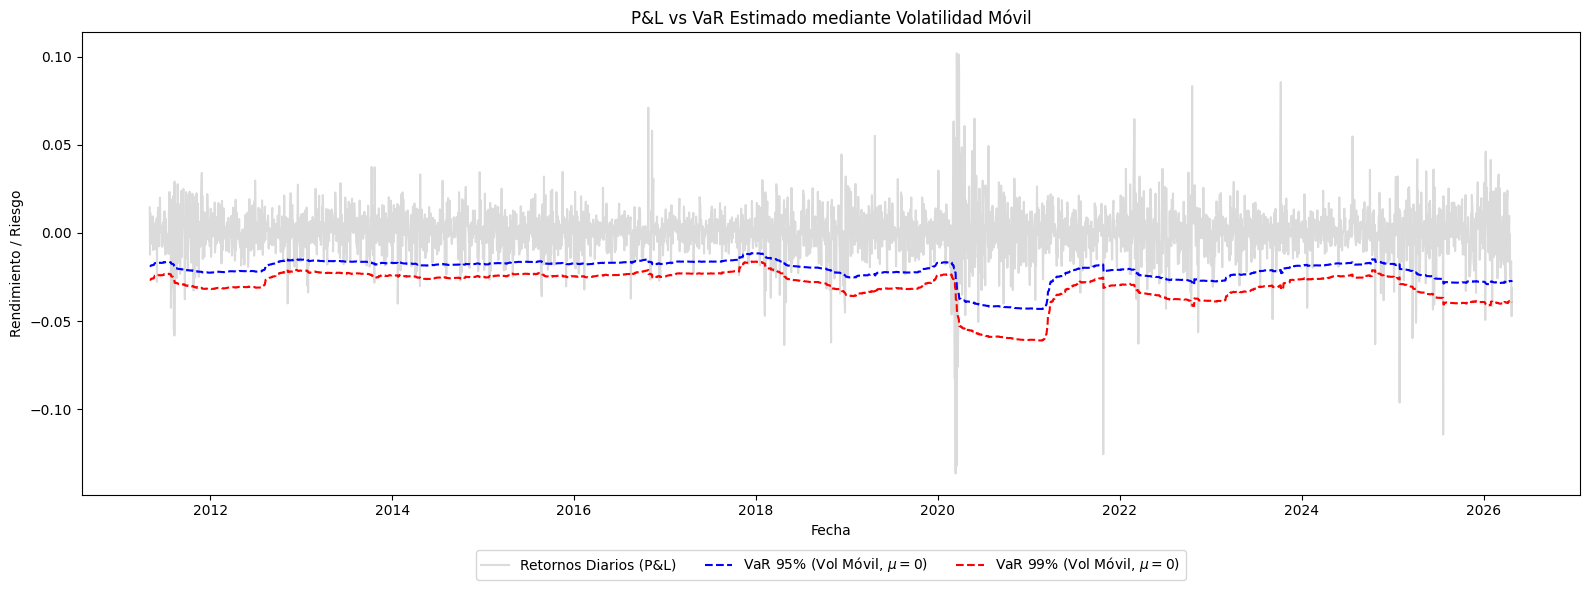

In [22]:
plt.figure(figsize=(16, 6))

# Retornos
plt.plot(df_var_vol.index, df_var_vol['Return'], color='lightgrey', alpha=0.8, label='Retornos Diarios (P&L)')

# VaR 95% y 99% con Volatilidad Móvil
plt.plot(df_var_vol.index, df_var_vol['VaR_95_VolMovil'], color='blue', linestyle='--', linewidth=1.5, label='VaR 95% (Vol Móvil, $\mu=0$)')
plt.plot(df_var_vol.index, df_var_vol['VaR_99_VolMovil'], color='red', linestyle='--', linewidth=1.5, label='VaR 99% (Vol Móvil, $\mu=0$)')

plt.title("P&L vs VaR Estimado mediante Volatilidad Móvil")
plt.xlabel("Fecha")
plt.ylabel("Rendimiento / Riesgo")
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=3)
plt.tight_layout()
plt.show()

In [23]:
# =====================================================================
# BACKTESTING DE EFICIENCIA (VIOLACIONES)
# =====================================================================

n_obs_vol = len(df_var_vol)
resultados_vol = []

for alpha in alphas_sig:
    confianza = int((1 - alpha) * 100)
    col_name = f'VaR_{confianza}_VolMovil'
    
    # Condición de violación: r_t < VaR_t
    num_violaciones = (df_var_vol['Return'] < df_var_vol[col_name]).sum()
    pct_violaciones = (num_violaciones / n_obs_vol) * 100
    
    resultados_vol.append({
        'Medida': 'VaR (Vol Móvil)',
        'Significancia (alpha)': alpha,
        'Nivel de Confianza': f'{confianza}%',
        '# Violaciones': num_violaciones,
        '% de Violaciones': pct_violaciones
    })

df_res_vol = pd.DataFrame(resultados_vol)

print("\n" + "="*55)
print("   EFICIENCIA DEL MODELO: VOLATILIDAD MÓVIL (VaR)   ")
print("="*55)
print(f"Total de días evaluados (n): {n_obs_vol}")
print("-" * 55)
print(df_res_vol.to_string(index=False, float_format="%.2f%%"))
print("="*55)


   EFICIENCIA DEL MODELO: VOLATILIDAD MÓVIL (VaR)   
Total de días evaluados (n): 3767
-------------------------------------------------------
         Medida  Significancia (alpha) Nivel de Confianza  # Violaciones  % de Violaciones
VaR (Vol Móvil)                  0.05%                95%            160             4.25%
VaR (Vol Móvil)                  0.01%                99%             77             2.04%
